# Axicon 1 (α = 5°) — measured Bessel zone vs Rao theory vs QDHT model

**Dataset**: four 2026-07-28 auto-scans after the optics rearrangement, input =
post-telescope Gaussian, D = 9.50 mm (1/e² **diameter**, adopted mean from
`beam_gaussian_fit_analysis_2026_07_24` — the scan prompt's
`GaussianBeamWaist_mm: 9.5` records this diameter, so w₀ = 4.75 mm). 69 X–Z
slices at 0.5 cm pitch, y = 4.70–32.60 cm after the axicon
(`MeasuredFrom: "axicon1"`):

| run | slices | y (cm) | covers |
|---|---|---|---|
| `auto_scan-2026-07-28_18-05-28` | 25 | 4.70–16.70 | Bessel zone + envelope peak |
| `auto_scan-2026-07-28_17-08-33` | 25 | 13.70–25.70 | envelope tail |
| `auto_scan-2026-07-28_15-18-35` | 14 | 23.60–30.10 | annulus handoff |
| `auto_scan-2026-07-28_16-27-38` | 5 | 30.60–32.60 | annulus handoff tail |

**Predictions** (λ = 650 nm, w₀ = 4.75 mm):

| quantity | Rao (n = 1.457, k·sin((n−1)α)) | QDHT (n = 1.4585, k·(n−1)·tanα) |
|---|---|---|
| k_r | 3.854×10⁵ rad/m | 3.878×10⁵ rad/m (+0.6 %) |
| zmax = k·w₀/k_r | 11.91 cm | 11.84 cm |
| envelope peak (zmax/2) | 5.96 cm | — |
| core first zero 2.405/k_r | 6.24 µm | 6.20 µm |
| J₀² fringe period π/k_r | 8.15 µm | 8.10 µm |

The two modules use slightly different refractive indices and small-angle
conventions; the 0.6 % k_r difference is invisible at our resolution, so both
are shown as-is.

First comparison — **axial**: per-slice peak-pixel rate (best unsaturated
`Max` ÷ its `Exposure_us`) vs the Rao envelope
I(z) ∝ (z/zmax)·exp(−2(z/zmax)²) and the QDHT on-axis curve for a single
axicon on the measured Gaussian. Radial J₀² profiles and the slice gallery
follow in later sections.


In [1]:
import glob
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j0

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "profiler"))

from simulator.bessel_axicon import AxiconParams, axial_envelope, zmax_axicon
from simulator.qdht_axicon import (QDHT, propagate_spectrum, axicon_kr, K0,
                                   mm as MM)

RUNS = ["auto_scan-2026-07-28_18-05-28",   # ordered by y coverage, not clock
        "auto_scan-2026-07-28_17-08-33",
        "auto_scan-2026-07-28_15-18-35",
        "auto_scan-2026-07-28_16-27-38"]
RUN_DIRS = {r: REPO / "profiler/data" / r for r in RUNS}
PX_UM = 3.45                     # native camera pixel (µm)
D_IN_MM = 9.50                   # 1/e² input diameter after telescope
W0_UM = D_IN_MM * 1e3 / 2        # 1/e² radius, µm
ALPHA_DEG = 5.0

P = AxiconParams(wavelength_nm=650, n=1.457, alpha_deg=ALPHA_DEG)
KR_RAO = P.k_r
ZMAX_M = zmax_axicon(W0_UM, P)
KR_Q = axicon_kr(ALPHA_DEG)
print(f"k_r: Rao {KR_RAO:.4e}, QDHT {KR_Q:.4e} rad/m "
      f"({100 * (KR_Q / KR_RAO - 1):+.2f} %)")
print(f"zmax = {ZMAX_M * 100:.2f} cm, envelope peak at {ZMAX_M * 50:.2f} cm")
print(f"core first zero {2.405 / KR_RAO * 1e6:.2f} µm, "
      f"fringe period {np.pi / KR_RAO * 1e6:.2f} µm")

# Every figure is also written out as images/<notebook filename>/<description>.png.
NOTEBOOK_STEM = "axicon1_bessel_analysis_2026_07_28"
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
def save_fig(description):
    path = IMAGES_DIR / f"{description}.png"
    plt.gcf().savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved {path}")

k_r: Rao 3.8540e+05, QDHT 3.8776e+05 rad/m (+0.61 %)
zmax = 11.91 cm, envelope peak at 5.96 cm
core first zero 6.24 µm, fringe period 8.15 µm


## Axial reduction — peak-pixel rate per slice

For each slice, the metric is the maximum over unsaturated lit frames of
`Max / Exposure_us` (counts/µs) — an exposure-independent stand-in for peak
intensity. A slice where **every** lit frame saturated is kept as a **lower
bound** (`lower_bound`, best rate over the saturated frames) rather than
dropped — that is the 10.2–15.7 cm stretch of run `18-05-28`, where the
headless calibration limit-cycled at core-saturating exposures (the
neighbor-validated `robust_max` fix landed the same night; rescan with
`--max-exposure` if mid-zone absolute rates matter). A slice is **flagged**
when it is a lower bound *or* its best unsaturated frame needed an
anomalously long exposure (> 10 ms): the find-beam ×-escalation landing on
the dim annulus-transition region, not comparable to the rest.

The reduction is cached in `reductions/ax1_reduction_2026_07_28.json`
(delete it to force a re-reduction from the four runs' manifests; composites
are ensured as a side-effect for anyone re-running slice imagery later).


In [2]:
# --- ensure composites + reduce frames.jsonl -> peak rate per slice ---------
CACHE = Path("reductions/ax1_reduction_2026_07_28.json")

if CACHE.exists():
    reduction = json.load(open(CACHE))
    print(f"loaded cached reduction ({len(reduction)} slices)")
else:
    # profiler imports only needed on the rebuild path (cache-hit runs stay
    # dependency-light)
    from composite import CompositeConfig, composite_slice
    cfg = CompositeConfig(PixelSize_um=PX_UM, Downsample=2, FlipX=True,
                          FlipZ=True, Transpose=False, SubtractBackground=True,
                          IncludeDarkFrames=False, Colormap="inferno")
    reduction = []
    for run in RUNS:
        for sd in sorted(glob.glob(str(RUN_DIRS[run] / "y*cm"))):
            sd = Path(sd)
            if not (sd / "composite_meta.json").exists():
                try:
                    composite_slice(str(sd), cfg)
                except Exception as e:
                    # a slice that cannot composite still reduces from its
                    # manifest below, but say so rather than hiding it
                    print(f"COMPOSITE FAIL {sd.name}: {type(e).__name__}: {e}")
            lit, sat = [], []
            for line in open(sd / "frames.jsonl"):
                if not line.strip():
                    continue
                rec = json.loads(line)
                name = Path(rec["Path"]).name
                if "background" in name or "-dark" in name:
                    continue
                (sat if rec.get("SaturatedPixelCount", 0) > 0
                 else lit).append(rec)
            pool = lit if lit else sat        # all-saturated -> lower bound
            if not pool:
                print(f"EMPTY SLICE {run}/{sd.name}: no lit or saturated frames")
                continue
            best = max(pool, key=lambda r: r["Max"] / r["Extra"]["Exposure_us"])
            reduction.append(dict(
                run=run, slice=sd.name,
                beam_y_cm=best["Extra"]["BeamY_mm"] / 10.0,
                n_lit=len(lit), n_sat=len(sat), lower_bound=not lit,
                peak=dict(rate=best["Max"] / best["Extra"]["Exposure_us"],
                          max=best["Max"], T=best["Extra"]["Exposure_us"],
                          path=Path(best["Path"]).name,
                          x=best["GantryPosition_mm"]["x_mm"],
                          z=best["GantryPosition_mm"]["z_mm"])))
    CACHE.parent.mkdir(exist_ok=True)
    json.dump(reduction, open(CACHE, "w"))
    print(f"reduced and cached {len(reduction)} slices")

y_all = np.array([s["beam_y_cm"] for s in reduction])
rate_all = np.array([s["peak"]["rate"] for s in reduction])
run_all = np.array([s["run"] for s in reduction])
flagged = np.array([s["lower_bound"] or (s["n_sat"] > 0 and s["peak"]["T"] > 10_000)
                    for s in reduction])
for i, s in enumerate(reduction):
    p = s["peak"]
    print(f"{s['run'][-8:]}  y={s['beam_y_cm']:5.2f}  "
          f"rate={p['rate']:9.3e} counts/µs  max={p['max']:3.0f}  "
          f"T={p['T'] / 1e3:7.2f} ms  sat={s['n_sat']:2d}"
          + ("  ** LOWER BOUND" if s["lower_bound"]
             else "  ** FLAGGED" if flagged[i] else ""))

loaded cached reduction (69 slices)
18-05-28  y= 4.70  rate=2.112e+00 counts/µs  max=132  T=   0.06 ms  sat= 0
18-05-28  y= 5.20  rate=2.240e+00 counts/µs  max=140  T=   0.06 ms  sat= 0
18-05-28  y= 5.70  rate=2.576e+00 counts/µs  max=161  T=   0.06 ms  sat= 0
18-05-28  y= 6.20  rate=2.528e+00 counts/µs  max=158  T=   0.06 ms  sat= 0
18-05-28  y= 6.70  rate=1.792e+00 counts/µs  max=112  T=   0.06 ms  sat= 0
18-05-28  y= 7.20  rate=2.336e+00 counts/µs  max=146  T=   0.06 ms  sat= 0
18-05-28  y= 7.70  rate=2.048e+00 counts/µs  max=128  T=   0.06 ms  sat= 0
18-05-28  y= 8.20  rate=1.760e+00 counts/µs  max=110  T=   0.06 ms  sat= 0
18-05-28  y= 8.70  rate=1.808e+00 counts/µs  max=113  T=   0.06 ms  sat= 0
18-05-28  y= 9.20  rate=1.680e+00 counts/µs  max=105  T=   0.06 ms  sat= 0
18-05-28  y= 9.70  rate=1.631e+00 counts/µs  max=101  T=   0.06 ms  sat= 0
18-05-28  y=10.20  rate=2.574e-01 counts/µs  max=255  T=   0.99 ms  sat= 1  ** LOWER BOUND
18-05-28  y=10.70  rate=2.574e-01 counts/µs  max

## Pixel sampling of a 6 µm core — expected scatter of the metric

The Bessel core (first zero 6.2 µm, FWHM ≈ 5.8 µm) is barely wider than one
3.45 µm pixel, so the *peak-pixel* value depends on where the core lands
relative to the pixel grid. Averaging J₀²(k_r·r) over one pixel: a
core-centered pixel reads 0.86 of the true on-axis intensity; a
corner-straddling core reads 0.56. The metric therefore scatters over
roughly **[0.56, 0.86] × I(0)** slice-to-slice — a ±20 % band, biased low —
and that is the dominant noise on the axial plot (exposures are known to
0.1 µs; counts to 1 part in ~130).


In [3]:
# --- peak-pixel acceptance band from sub-pixel alignment ---------------------
g = (np.arange(24) + 0.5) / 24 * PX_UM - PX_UM / 2
GX, GY = np.meshgrid(g, g)

def peak_pixel_frac(ox_um, oy_um):
    """Pixel-average of the normalized core at sub-pixel offset (ox, oy)."""
    r = np.hypot(GX - ox_um, GY - oy_um) * 1e-6
    return (j0(KR_RAO * r) ** 2).mean()

f_best = peak_pixel_frac(0, 0)
f_worst = peak_pixel_frac(PX_UM / 2, PX_UM / 2)
print(f"peak-pixel fraction of true I(0): centered {f_best:.3f}, "
      f"corner {f_worst:.3f} -> {100 * (1 - f_worst / f_best):.0f} % scatter")

peak-pixel fraction of true I(0): centered 0.864, corner 0.564 -> 35 % scatter


saved images/axicon1_bessel_analysis_2026_07_28/axial_vs_theory.png


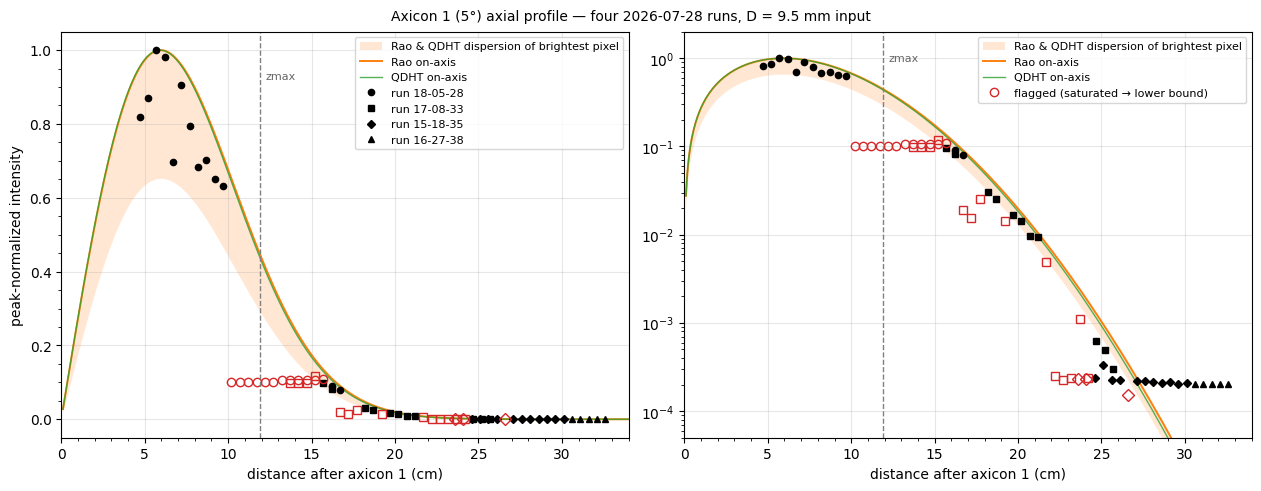

In [4]:
# --- axial comparison figure -------------------------------------------------
z_fine = np.linspace(1e-3, 0.34, 600)
rao = axial_envelope(z_fine, W0_UM, P)
rao = rao / rao.max()

# the domain must still contain the departing annulus at 34 cm (θ·z + tail),
# which forces N up with it to keep the radial grid resolving the cone
N_Q, R_Q = 8192, 26 * MM
q = QDHT(N_Q, R_Q)
assert q.kr_max > 2.5 * KR_Q, "radial grid too coarse for the axicon cone"
assert R_Q > KR_Q / K0 * z_fine[-1] + 2.5 * W0_UM * 1e-6, \
    "annulus reaches the domain wall inside the plotted range"
E0 = np.exp(-(q.r / (W0_UM * 1e-6)) ** 2) * np.exp(-1j * KR_Q * q.r)
qd_onax = q.onax(propagate_spectrum(q.forward(E0), q.kr, K0, z_fine))
qd_onax = qd_onax / qd_onax.max()

ok = ~flagged
norm = rate_all / rate_all[ok].max()
MARKER = dict(zip(RUNS, "osD^"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8),
                               constrained_layout=True)
for ax in (ax1, ax2):
    ax.fill_between(z_fine * 100, rao * f_worst / f_best, rao,
                    color="tab:orange", alpha=0.18, lw=0,
                    label="Rao & QDHT dispersion of brightest pixel")
    ax.plot(z_fine * 100, rao, "-", color="tab:orange", lw=1.4,
            label="Rao on-axis")
    ax.plot(z_fine * 100, qd_onax, "-", color="tab:green", lw=1.0, alpha=0.8,
            label="QDHT on-axis")
    for r in RUNS:
        m = ok & (run_all == r)
        ax.plot(y_all[m], norm[m], MARKER[r], color="k", ms=4.5, lw=0,
                label=f"run {r[-8:]}" if ax is ax1 else None)
    for r in RUNS:                    # flagged: hollow red, same run shapes
        m = flagged & (run_all == r)
        ax.plot(y_all[m], norm[m], MARKER[r], mfc="none", mec="tab:red",
                ms=6, lw=0)
    ax.axvline(ZMAX_M * 100, color="0.5", ls="--", lw=1)
    ax.annotate("zmax", (ZMAX_M * 100 + 0.3, 0.92), fontsize=8, color="0.4")
    ax.set_xlabel("distance after axicon 1 (cm)")
    ax.set_xlim(0, 34)
    ax.minorticks_on(); ax.grid(True, alpha=0.3)
ax1.set_ylabel("peak-normalized intensity")
ax1.legend(fontsize=8)
ax2.plot([], [], "o", mfc="none", mec="tab:red", ms=6,
         label="flagged (saturated → lower bound)")
ax2.set_yscale("log"); ax2.set_ylim(5e-5, 2)
ax2.legend(fontsize=8)
fig.suptitle(f"Axicon 1 ({ALPHA_DEG:g}°) axial profile — four 2026-07-28 "
             f"runs, D = {D_IN_MM:g} mm input", fontsize=10)
save_fig("axial_vs_theory")
plt.show()

### Reading the axial comparison

- **The envelope shape is confirmed over ~3 decades, with no fitted
  parameters.** The measured peak lands at 5.7–6.2 cm vs 5.96 cm predicted
  from D = 9.50 mm and the axicon prescription alone, and the log panel
  tracks the (z/zmax)·exp(−2(z/zmax)²) rolloff from the peak down to
  ~2×10⁻⁴ at 27 cm. This is also an independent re-confirmation that the
  9.5 mm figure is the 1/e² **diameter**: read as a radius, zmax would double
  and the peak would sit at ~12 cm, nowhere near the data.
- **Rao and QDHT agree with each other** to line width on-axis, as for a
  single 5° axicon on a clean Gaussian they must; the comparison tests the
  measurement, and it passes.
- **The scatter in 4.7–10 cm is pixel sampling, not the beam**: points
  bounce within the shaded band exactly as the sub-pixel argument predicts
  (a ~6 µm core on a 3.45 µm grid).
- **Past ~27 cm the metric plateaus at ~2×10⁻⁴ of peak**: the brightest
  pixel is no longer the on-axis core but the brightest fringe of the
  departing annulus, so the peak-pixel metric parts company with the on-axis
  curves — expected, and mapped here over 27–32.6 cm because this is the
  input axicon 2 will see. The axial *model* comparison only applies left of
  the handoff.
- **Hollow red markers are not measurements.** The 10.2–15.7 cm stretch of
  run `18-05-28` saturated every lit frame (calibration limit cycle, since
  fixed) — those lower bounds sit flat near 0.1 of peak, an artifact of
  8-bit `Max` = 255 at the calibration's stuck exposure. The remaining
  flags (runs `17-08-33`, `15-18-35`) are >10 ms best-exposure slices in the
  dim transition region.
- **Cross-run consistency**: the one unflagged duplicate plane (y = 16.2 cm,
  runs `18-05-28` vs `17-08-33`) repeats to 11 % — within the pixel-sampling
  band — and the run-to-run seams at 25.7/23.6 cm and 30.1/30.6 cm are
  seamless on the log panel despite independent exposure calibrations.
  In-zone core exposures sat at ~62 µs (rates 1.6–2.6 counts/µs), so the
  unflagged zone was measured comfortably within 8-bit depth.


## X–Z slice gallery

The jul13/jul23-style grid, for all 69 slices of the four runs: each panel is
the slice's frames mosaicked at their gantry positions from the **pooled
per-slice cache** (`profiler/data/reductions_jul28/`, 8×8-pooled 27.6 µm
pixels, counts/µs) — light enough to rerun anywhere; any missing slice is
re-reduced from its raw frames (loudly, and only if the raw run directory is
present). Pooled frames are stored in **raw camera orientation** — the camera
is mounted 180° rotated vs the machine axes, so each frame is rotated
(FlipX + FlipZ) before placement, exactly as the composite tool does.

Panels are normalized per-panel on a sqrt scale and framed at
max(1.3·r_ring, 3 mm) about the intensity centroid; gray = outside
adaptive-raster coverage. Duplicated y values (run overlap) appear as
adjacent panels. Flags carry over from the axial reduction: **LB** =
all lit frames saturated (calibration limit cycle — the blown-out core is an
artifact), **SAT** = saturated frames present with >10 ms best exposure.
The progression to look for: a bare J₀ core through the Bessel zone, the
halo brightening as the envelope dies, the annulus emerging at ~22 cm, and
a clean departing ring past 27 cm — the input axicon 2 will see.


In [5]:
# --- pooled-cache load: mosaic each slice at its gantry positions -----------
POOL = 8
PX_POOL_MM = PX_UM * 1e-3 * POOL   # 27.6 um pooled pixel, mm
CORE_EXCLUDE_MM = 1.5              # on-axis core, excluded from ring search
RED_ROOT = REPO / "profiler/data/reductions_jul28"


def _coord(name, tag):
    i = name.index(tag) + len(tag)
    sign = 1.0 if name[i] == "p" else -1.0
    return sign * float(name[i + 1:name.index("mm", i)])


def pool8(a):
    r, c = a.shape
    r8, c8 = r - r % POOL, c - c % POOL
    return (a[:r8, :c8].reshape(r8 // POOL, POOL, c8 // POOL, POOL)
            .mean(axis=(1, 3)).astype(np.float16))


def reduce_slice(slice_dir, out_path):
    """Rebuild one slice's pooled npz from raw frames (jul28 scan-analysis
    reduction, recovered from 13fd9d06)."""
    cal = json.loads((slice_dir / "calibration_result.json").read_text())
    frames, xs, zs, rmax, n_dark = [], [], [], [], 0
    for p in sorted(slice_dir.glob("*.npy")):
        if "background" in p.name or "gantryx" not in p.name:
            continue
        if "-dark" in p.name:
            n_dark += 1
            continue
        a = np.load(p)
        xs.append(_coord(p.name, "gantryx")); zs.append(_coord(p.name, "-z"))
        rmax.append(int(a.max())); frames.append(pool8(a))
    bg = json.loads((slice_dir / "background_reference.json").read_text())
    bg_frames = [np.load(slice_dir.parent / Path(bp).parent.name / Path(bp).name)
                 .astype(np.float32)
                 for bp in bg.get("BackgroundPaths", [])
                 if (slice_dir.parent / Path(bp).parent.name / Path(bp).name).exists()]
    np.savez_compressed(
        out_path,
        frames=np.array(frames) if frames else np.zeros((0, 192, 256), np.float16),
        xs=np.array(xs), zs=np.array(zs), raw_max=np.array(rmax), n_dark=n_dark,
        exposure_us=cal["FinalExposure_us"],
        beam_y_mm=cal["BeamY_mm"], machine_y_mm=cal["MachineY_mm"],
        bg_mean=pool8(np.mean(bg_frames, axis=0)) if bg_frames else np.zeros((0, 0), np.float16),
        bg_exposure_us=bg.get("BackgroundExposure_us") or 0.0)


def composite_of(frames, xs, zs, bg):
    """Overlap-averaged mosaic in machine coords; camera is 180 deg rotated
    vs machine axes (FlipX AND FlipZ, hardware-verified 2026-07-22)."""
    rows, cols = frames.shape[1:]
    fw, fh = cols * PX_POOL_MM, rows * PX_POOL_MM
    x_left, z_top = xs.min() - fw / 2, zs.max() + fh / 2
    ncols = int(round((xs.max() - xs.min() + fw) / PX_POOL_MM))
    nrows = int(round((zs.max() - zs.min() + fh) / PX_POOL_MM))
    total = np.zeros((nrows, ncols))
    count = np.zeros((nrows, ncols), int)
    for frame, x, z in zip(frames, xs, zs):
        f = frame[::-1, ::-1] - (bg[::-1, ::-1] if bg is not None else 0.0)
        r0 = int(round((z_top - (z + fh / 2)) / PX_POOL_MM))
        c0 = int(round((x - fw / 2 - x_left) / PX_POOL_MM))
        total[r0:r0 + rows, c0:c0 + cols] += f
        count[r0:r0 + rows, c0:c0 + cols] += 1
    canvas = np.full_like(total, np.nan)
    cov = count > 0
    canvas[cov] = np.clip(total[cov] / count[cov], 0.0, None)
    return canvas, (x_left, x_left + ncols * PX_POOL_MM,
                    z_top - nrows * PX_POOL_MM, z_top)


def panel_metrics(canvas, extent):
    """Intensity centroid + dominant ring radius (core-excluded)."""
    filled = np.nan_to_num(canvas, nan=0.0)
    if filled.max() <= 0:
        return None
    ny, nx = filled.shape
    x = np.linspace(extent[0], extent[1], nx)
    z = np.linspace(extent[3], extent[2], ny)
    X, Z = np.meshgrid(x, z)
    w = np.clip(filled, 0, None)
    cx, cz = (w * X).sum() / w.sum(), (w * Z).sum() / w.sum()
    rbin = (np.hypot(X - cx, Z - cz) / PX_POOL_MM).astype(int)
    prof = np.bincount(rbin.ravel(), weights=filled.ravel())
    norm_ = np.bincount(rbin.ravel(),
                        weights=np.isfinite(canvas).ravel().astype(float))
    prof = np.where(norm_ > 0, prof / np.maximum(norm_, 1), 0.0)
    core_px = max(1, int(round(CORE_EXCLUDE_MM / PX_POOL_MM)))
    if prof.size <= core_px:
        return None
    i_pk = core_px + int(np.argmax(prof[core_px:]))
    return dict(cx=cx, cz=cz, r_peak_mm=i_pk * PX_POOL_MM)


slice_flags = {(s["run"], s["slice"]):
               ("LB" if s["lower_bound"] else
                "SAT" if (s["n_sat"] > 0 and s["peak"]["T"] > 10_000) else "")
               for s in reduction}

gallery = []
for run in RUNS:
    for s in [r for r in reduction if r["run"] == run]:
        npz_path = RED_ROOT / run / (s["slice"] + ".npz")
        if not npz_path.exists():
            raw_dir = RUN_DIRS[run] / s["slice"]
            if raw_dir.is_dir():
                print(f"rebuilding pooled cache for {run}/{s['slice']} from raw")
                npz_path.parent.mkdir(parents=True, exist_ok=True)
                reduce_slice(raw_dir, npz_path)
            else:
                print(f"MISSING {run}/{s['slice']}: no pooled npz and no raw "
                      f"frames — this slice will be absent from the gallery")
                continue
        d = np.load(npz_path)
        if d["frames"].shape[0] == 0:
            print(f"EMPTY {run}/{s['slice']}: cache has no lit frames — skipped")
            continue
        bg = d["bg_mean"].astype(np.float32) if d["bg_mean"].size else None
        canvas, ext = composite_of(d["frames"].astype(np.float32),
                                   d["xs"].astype(float),
                                   d["zs"].astype(float), bg)
        gallery.append(dict(run=run, name=s["slice"],
                            y=float(d["beam_y_mm"]) / 10.0,
                            exposure_us=float(d["exposure_us"]),
                            canvas=canvas, extent=ext,
                            metrics=panel_metrics(canvas, ext),
                            flag=slice_flags[(run, s["slice"])]))
gallery.sort(key=lambda s: (s["y"], s["run"]))
print(f"{len(gallery)} slice mosaics ready")

69 slice mosaics ready


saved images/axicon1_bessel_analysis_2026_07_28/xz_slice_gallery.png


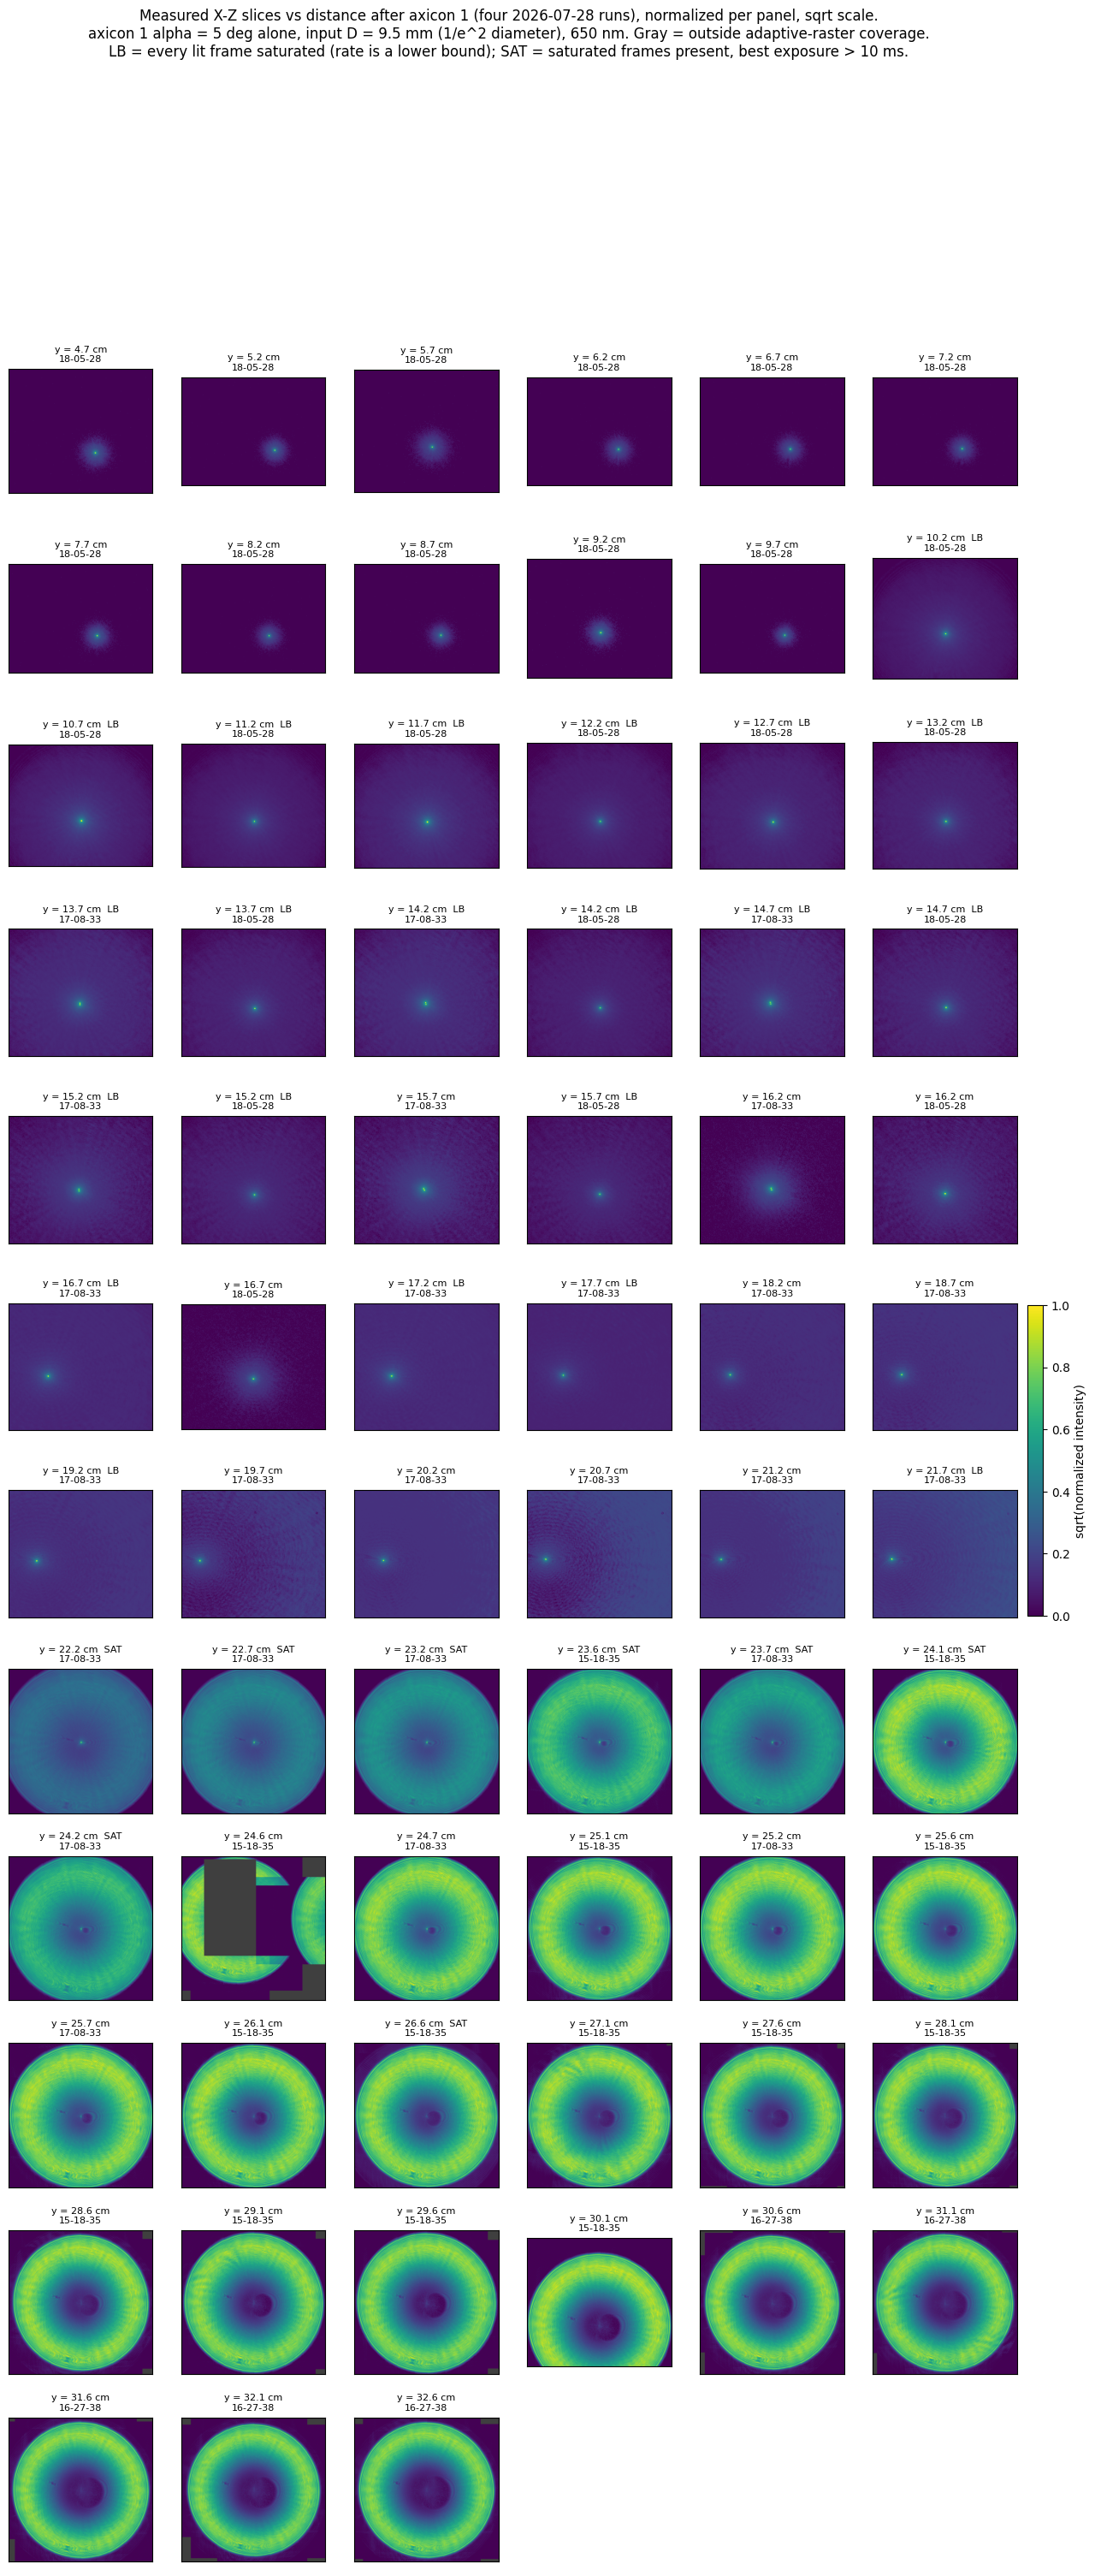

In [6]:
# --- gallery figure ----------------------------------------------------------
N_COLS = 6
n_rows = int(np.ceil(len(gallery) / N_COLS))
cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("0.25")
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(2.6 * N_COLS, 2.8 * n_rows))
for ax in np.ravel(axes):
    ax.set_axis_off()
for ax, s in zip(np.ravel(axes), gallery):
    ax.set_axis_on()
    ax.set_xticks([]); ax.set_yticks([])
    img = np.sqrt(np.clip(s["canvas"] / np.nanmax(s["canvas"]), 0, 1))
    im = ax.imshow(img, extent=s["extent"], cmap=cmap, vmin=0, vmax=1)
    m = s["metrics"]
    if m:
        half = max(1.3 * m["r_peak_mm"], 3.0)
        e = s["extent"]
        ax.set_xlim(max(m["cx"] - half, e[0]), min(m["cx"] + half, e[1]))
        ax.set_ylim(max(m["cz"] - half, e[2]), min(m["cz"] + half, e[3]))
    ax.set_title(f"y = {s['y']:g} cm" + (f"  {s['flag']}" if s["flag"] else "")
                 + f"\n{s['run'][-8:]}", fontsize=8)
fig.suptitle(
    "Measured X-Z slices vs distance after axicon 1 (four 2026-07-28 runs), "
    "normalized per panel, sqrt scale.\n"
    f"axicon 1 alpha = {ALPHA_DEG:g} deg alone, input D = {D_IN_MM:g} mm "
    "(1/e^2 diameter), 650 nm. Gray = outside adaptive-raster coverage.\n"
    "LB = every lit frame saturated (rate is a lower bound); SAT = saturated "
    "frames present, best exposure > 10 ms.", y=1.0, fontsize=12)
fig.colorbar(im, ax=axes, label="sqrt(normalized intensity)",
             fraction=0.015, pad=0.01)
save_fig("xz_slice_gallery")
plt.show()

## Annulus at the axicon-2 plane (L12 = 240 mm)

Axicon 2 sits **240 mm** after axicon 1 — at L12/zmax = 2.0, *below* the
~2.4–2.7×zmax "clean annulus" threshold from the jul23 L12 sweep, and left of
the ~27 cm peak-pixel handoff: the annulus axicon 2 receives is still
forming, with the residual core alive at its center (the saturated frames in
the 22–24 cm slices *are* that core). This section characterizes that input
from the ring mosaics: azimuthal-mean radial profile, ring peak radius and
FWHM vs distance, and azimuthal uniformity in the ring band — against the
QDHT single-axicon field evaluated on the same 27.6 µm pooled grid.

Method notes: ring center = intensity centroid iterated with the r < 1.5 mm
core masked; slices whose ring-band azimuthal scatter exceeds 10 % rms are
excluded from fits as mosaic-coverage artifacts (the y = 24.6 and 30.1 cm
panels with gray holes in the gallery), not beam physics. In the still-forming
region the ring radius is **not** θ·y: rays from the Gaussian peak dominate
only asymptotically, where r → θ·y − w₀/2 (the r₀-jacobian shifts the fold
peak); QDHT is the honest comparator at finite y — this is what produced the
removed grid-notebook's puzzling "−2.3 % deflection with −2.3 mm parallel
offset": a straight θ·y fit to a curved, offset relation.


In [7]:
# --- ring metrics per slice + QDHT comparator --------------------------------
def ring_analysis(canvas, extent, exposure_us):
    """Core-masked centroid, azimuthal-mean radial profile, ring peak/FWHM,
    azimuthal profile in the ring band. Rates in counts/us."""
    ny, nx = canvas.shape
    X = extent[0] + (np.arange(nx) + .5) * PX_POOL_MM
    Z = extent[3] - (np.arange(ny) + .5) * PX_POOL_MM
    XX, ZZ = np.meshgrid(X, Z)
    fil = np.nan_to_num(canvas)
    w = fil.copy()
    for _ in range(3):                      # centroid, core-masked iterations
        cx, cz = (w * XX).sum() / w.sum(), (w * ZZ).sum() / w.sum()
        w = np.where(np.hypot(XX - cx, ZZ - cz) > CORE_EXCLUDE_MM, fil, 0.0)
    R = np.hypot(XX - cx, ZZ - cz)
    rbin = (R / PX_POOL_MM).astype(int)
    fin = np.isfinite(canvas)
    npx = np.bincount(rbin[fin])
    prof = np.bincount(rbin[fin], weights=canvas[fin])
    prof = np.where(npx > 0, prof / np.maximum(npx, 1), np.nan)
    r_mm = (np.arange(prof.size) + .5) * PX_POOL_MM
    core_px = int(round(CORE_EXCLUDE_MM / PX_POOL_MM))
    pv = np.nan_to_num(prof)
    pv[:core_px] = 0
    i_pk = int(np.argmax(pv))
    half = pv[i_pk] / 2
    lo = i_pk
    while lo > core_px and pv[lo] > half:
        lo -= 1
    hi = i_pk
    while hi < pv.size - 1 and pv[hi] > half:
        hi += 1
    band = np.abs(R - r_mm[i_pk]) < max((r_mm[hi] - r_mm[lo]) / 2, 3 * PX_POOL_MM)
    phi_bin = (((np.degrees(np.arctan2(ZZ - cz, XX - cx)) + 180) // 10)
               .astype(int).clip(0, 35))
    sel = band & fin
    ssum = np.bincount(phi_bin[sel], weights=canvas[sel], minlength=36)
    scnt = np.bincount(phi_bin[sel], minlength=36)
    az = np.where(scnt > 3, ssum / np.maximum(scnt, 1), np.nan)
    return dict(cx=cx, cz=cz, r_mm=r_mm, prof=prof / exposure_us,
                r_peak=r_mm[i_pk], fwhm=r_mm[hi] - r_mm[lo],
                az=az / exposure_us)


rings = []
for s in gallery:
    if s["y"] < 21.9:
        continue
    m = ring_analysis(s["canvas"], s["extent"], s["exposure_us"])
    m.update(y=s["y"], run=s["run"], flag=s["flag"])
    m["az_rms"] = float(np.nanstd(m["az"]) / np.nanmean(m["az"]))
    rings.append(m)
rings.sort(key=lambda m: (m["y"], m["run"]))
good = [m for m in rings if m["az_rms"] < 0.10]
bad = [m for m in rings if m["az_rms"] >= 0.10]
print(f"{len(rings)} ring slices, {len(bad)} excluded as mosaic artifacts: "
      f"{[(m['y'], m['run'][-8:]) for m in bad]}")

# QDHT single-axicon field on the pooled radial grid (reuses q from the
# axial section: N=8192, R=26 mm)
z_model = np.arange(0.20, 0.345, 0.005)
Y_ann = propagate_spectrum(q.forward(E0), q.kr, K0, z_model)
r_eval = np.arange(0.0, 14e-3, PX_POOL_MM * 1e-3)
EV = q.eval_matrix(r_eval)
core_j = np.searchsorted(r_eval, CORE_EXCLUDE_MM * 1e-3)
q_prof = {}
q_rpk, q_fwhm = [], []
for i, z in enumerate(z_model):
    I = np.abs(Y_ann[i] @ EV) ** 2
    j = core_j + int(np.argmax(I[core_j:]))
    half = I[j] / 2
    lo = j
    while lo > core_j and I[lo] > half:
        lo -= 1
    hi = j
    while hi < I.size - 1 and I[hi] > half:
        hi += 1
    q_prof[round(z * 1000)] = I
    q_rpk.append(r_eval[j] * 1e3)
    q_fwhm.append((r_eval[hi] - r_eval[lo]) * 1e3)
q_rpk, q_fwhm = np.array(q_rpk), np.array(q_fwhm)

y_g = np.array([m["y"] for m in good])
resid = np.array([m["r_peak"] for m in good]) - np.interp(y_g / 100, z_model, q_rpk)
print(f"ring radius residual vs QDHT: {resid.mean():+.2f} ± {resid.std():.2f} mm")
at_plane = [m for m in good if abs(m["y"] - 24.0) < 0.35]
for m in at_plane:
    print(f"AT PLANE y={m['y']:g} ({m['run'][-8:]}): r = {m['r_peak']:.2f} mm, "
          f"FWHM = {m['fwhm']:.2f} mm, azimuthal rms {100 * m['az_rms']:.1f} %")

27 ring slices, 2 excluded as mosaic artifacts: [(24.6, '15-18-35'), (30.1, '15-18-35')]


ring radius residual vs QDHT: +0.17 ± 0.13 mm
AT PLANE y=23.7 (17-08-33): r = 6.83 mm, FWHM = 5.27 mm, azimuthal rms 2.4 %
AT PLANE y=24.1 (15-18-35): r = 7.19 mm, FWHM = 5.19 mm, azimuthal rms 2.3 %
AT PLANE y=24.2 (17-08-33): r = 7.00 mm, FWHM = 5.27 mm, azimuthal rms 2.3 %


saved images/axicon1_bessel_analysis_2026_07_28/annulus_at_axicon2_plane.png


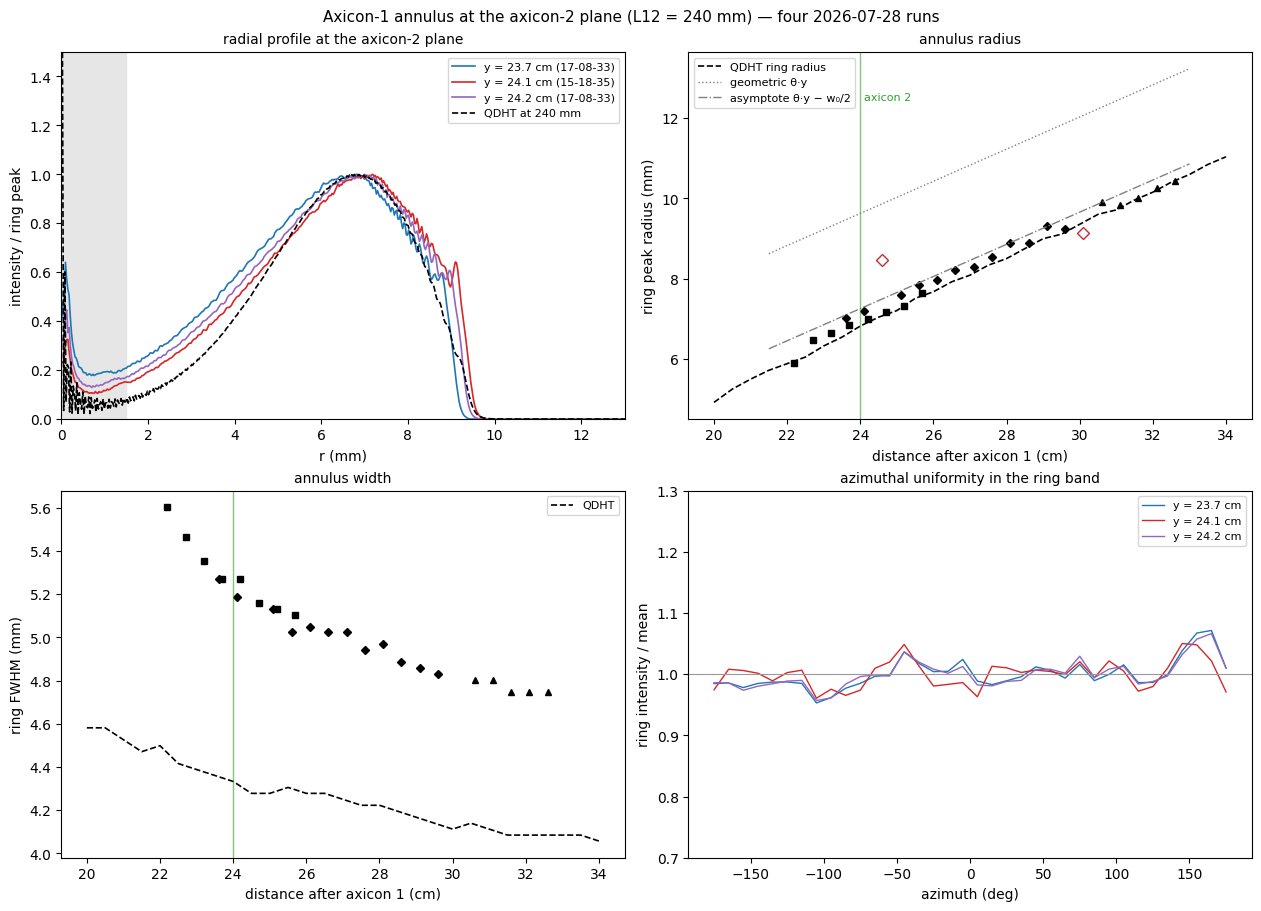

In [8]:
# --- annulus figure ----------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(12.5, 9), constrained_layout=True)

ax = axs[0, 0]      # radial profiles at the axicon-2 plane
for m, c in zip(at_plane, ["tab:blue", "tab:red", "tab:purple"]):
    core_i = int(round(CORE_EXCLUDE_MM / PX_POOL_MM))
    p = m["prof"] / np.nanmax(m["prof"][core_i:])
    ax.plot(m["r_mm"], p, "-", color=c, lw=1.2,
            label=f"y = {m['y']:g} cm ({m['run'][-8:]})")
Iq = q_prof[240] / q_prof[240][core_j:].max()
ax.plot(r_eval * 1e3, Iq, "k--", lw=1.2, label="QDHT at 240 mm")
ax.axvspan(0, CORE_EXCLUDE_MM, color="0.9")
ax.set_xlim(0, 13); ax.set_ylim(0, 1.5)
ax.set_xlabel("r (mm)"); ax.set_ylabel("intensity / ring peak")
ax.legend(fontsize=8)
ax.set_title("radial profile at the axicon-2 plane", fontsize=10)

ax = axs[0, 1]      # ring radius vs distance
for m in good:
    ax.plot(m["y"], m["r_peak"], MARKER[m["run"]], color="k", ms=4.5)
for m in bad:
    ax.plot(m["y"], m["r_peak"], MARKER[m["run"]], mfc="none", mec="tab:red",
            ms=6)
ax.plot(z_model * 100, q_rpk, "k--", lw=1.2, label="QDHT ring radius")
yy = np.linspace(21.5, 33, 40)
ax.plot(yy, (KR_Q / K0) * yy * 10, ":", color="0.5", lw=1, label="geometric θ·y")
ax.plot(yy, (KR_Q / K0) * yy * 10 - D_IN_MM / 4, "-.", color="0.5", lw=1,
        label="asymptote θ·y − w₀/2")
ax.axvline(24.0, color="tab:green", lw=1, alpha=0.6)
ax.annotate("axicon 2", (24.1, ax.get_ylim()[1] - 1.2), fontsize=8,
            color="tab:green")
ax.set_xlabel("distance after axicon 1 (cm)")
ax.set_ylabel("ring peak radius (mm)")
ax.legend(fontsize=8)
ax.set_title("annulus radius", fontsize=10)

ax = axs[1, 0]      # ring FWHM vs distance
for m in good:
    ax.plot(m["y"], m["fwhm"], MARKER[m["run"]], color="k", ms=4.5)
ax.plot(z_model * 100, q_fwhm, "k--", lw=1.2, label="QDHT")
ax.axvline(24.0, color="tab:green", lw=1, alpha=0.6)
ax.set_xlabel("distance after axicon 1 (cm)"); ax.set_ylabel("ring FWHM (mm)")
ax.legend(fontsize=8)
ax.set_title("annulus width", fontsize=10)

ax = axs[1, 1]      # azimuthal uniformity at the plane
phi = np.arange(36) * 10 - 175
for m, c in zip(at_plane, ["tab:blue", "tab:red", "tab:purple"]):
    ax.plot(phi, m["az"] / np.nanmean(m["az"]), "-", color=c, lw=1,
            label=f"y = {m['y']:g} cm")
ax.axhline(1, color="0.6", lw=0.8)
ax.set_ylim(0.7, 1.3)
ax.set_xlabel("azimuth (deg)"); ax.set_ylabel("ring intensity / mean")
ax.legend(fontsize=8)
ax.set_title("azimuthal uniformity in the ring band", fontsize=10)

fig.suptitle("Axicon-1 annulus at the axicon-2 plane (L12 = 240 mm) — "
             "four 2026-07-28 runs", fontsize=11)
save_fig("annulus_at_axicon2_plane")
plt.show()

### Reading the annulus comparison

- **What axicon 2 receives at 240 mm**: ring peak radius 6.8–7.2 mm
  (QDHT: 6.9 mm), FWHM 5.2–5.3 mm, azimuthally uniform to **2.3 % rms**
  (min/max ≈ 0.90) — and a residual on-axis core bright enough to saturate
  its frame at ring-calibrated exposures. The sharp outer edge and its
  position track the model closely.
- **Ring radius follows the QDHT curve, not θ·y**: residual
  +0.18 ± 0.13 mm (≈ +2 %) over 22.2–32.6 cm, while the geometric line runs
  ~2.5 mm above the data throughout. With the correct (curved) comparator,
  the removed grid-notebook's "deflection −2.3 % + parallel −2.3 mm" pair is
  resolved as a fit-form artifact; the remaining +2 % radius offset is at
  the level of the index/angle tolerance and per-placement distance anchor.
  Interleaved runs differ by ~0.3 mm at adjacent planes (15-18-35 high,
  17-08-33 low) — a per-placement y-anchor systematic worth remembering
  before quoting a deflection angle to better than a percent.
- **The ring is ~0.8 mm wider than the model**, almost entirely from an
  elevated inner flank (~2× the model's floor between core and ring). Extra
  light inside the ring is consistent with the jul23 near-axis excess
  (apex rounding / scatter); in the 22–24 cm slices the saturated core frame
  can also contribute inside r ≲ 3.5 mm. The outer flank matches.
- The two excluded slices (24.6, 30.1 cm) are the partial-mosaic panels
  visible in the gallery — coverage holes masquerading as azimuthal
  structure, not beam features.


## Near-axis r–y intensity map — measured vs QDHT

The streamlit-designer view, but from data: for every slice, the
azimuthal-mean radial profile of the **brightest raw frame** (native 3.45 µm
pixels, half-pixel bins, frame-median background, sub-pixel core centroid
from a 9×9 window), stacked into an r–y image and compared to the QDHT field
on the same grid. r ≤ 150 µm keeps the ~8 µm J₀² fringes resolvable on the
page. Both maps peak-normalized, γ = 0.5, like the designer plots.

Reading notes: columns are core-centered independently, so pointing drift is
removed by construction. Duplicated y keeps the unflagged (else brightest)
slice. Red triangles mark flagged columns — in 10.2–15.7 cm the clipped core
suppresses the column's absolute scale (the fringe *pattern* survives), and
the brightness step at 10 cm is that artifact, not physics. The model panel
is the un-sampled field: the measured fringe contrast is expected to sit
below it (8.1 µm fringes on 3.45 µm pixels — camera-limited, per the jul24
radial comparison).


62 map columns (23 flagged), max 2.58 counts/µs


saved images/axicon1_bessel_analysis_2026_07_28/near_axis_ry_map.png


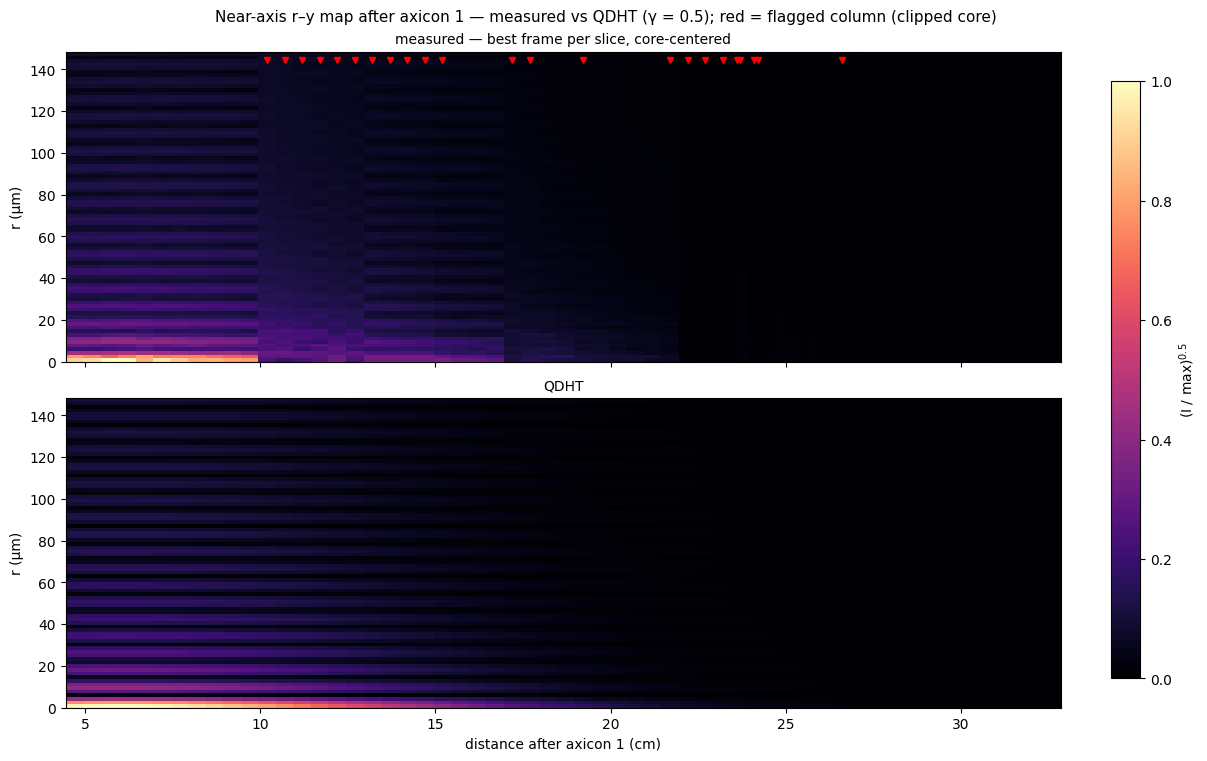

In [9]:
# --- near-axis r-y map: measured (best frame per slice) vs QDHT --------------
R_MAX_UM = 150.0
BIN_UM = PX_UM / 2

flag_by_slice = {(s["run"], s["slice"]): flagged[i]
                 for i, s in enumerate(reduction)}
by_y = {}
for s in reduction:                       # one slice per y
    k = round(s["beam_y_cm"], 2)
    cand = (flag_by_slice[(s["run"], s["slice"])], -s["peak"]["rate"])
    if k not in by_y or cand < by_y[k][0]:
        by_y[k] = (cand, s)

n_bin = int(R_MAX_UM / BIN_UM)
r_cent_um = (np.arange(n_bin) + .5) * BIN_UM
cols, ys_map, flags_map = [], [], []
for k in sorted(by_y):
    _, s = by_y[k]
    p = RUN_DIRS[s["run"]] / s["slice"] / s["peak"]["path"]
    if not p.exists():
        print(f"MISSING raw frame {p} — column y={k} left out of the map")
        continue
    a = np.load(p).astype(np.float32)
    bg = np.median(a)
    iy, ix = np.unravel_index(np.argmax(a), a.shape)
    w = np.clip(a[max(iy-4, 0):iy+5, max(ix-4, 0):ix+5] - bg, 0, None)
    wy, wx = np.mgrid[max(iy-4, 0):iy+5, max(ix-4, 0):ix+5]
    cy, cx = (w*wy).sum()/w.sum(), (w*wx).sum()/w.sum()
    yy, xx = np.mgrid[0:a.shape[0], 0:a.shape[1]]
    r_um = np.hypot(yy - cy, xx - cx) * PX_UM
    sel = r_um < R_MAX_UM
    b = (r_um[sel] / BIN_UM).astype(int).clip(0, n_bin - 1)
    prof = (np.bincount(b, weights=a[sel] - bg, minlength=n_bin)
            / np.maximum(np.bincount(b, minlength=n_bin), 1))
    cols.append(prof / s["peak"]["T"])           # counts/us
    ys_map.append(k)
    flags_map.append(flag_by_slice[(s["run"], s["slice"])])
M_meas = np.array(cols).T
ys_map, flags_map = np.array(ys_map), np.array(flags_map)
print(f"{len(ys_map)} map columns ({flags_map.sum()} flagged), "
      f"max {np.nanmax(M_meas):.2f} counts/µs")

Y_map = propagate_spectrum(q.forward(E0), q.kr, K0, ys_map / 100.0)
M_mod = (np.abs(Y_map @ q.eval_matrix(r_cent_um * 1e-6)) ** 2).T

ok_map = ~flags_map
edges = np.concatenate([[ys_map[0] - 0.25], (ys_map[:-1] + ys_map[1:]) / 2,
                        [ys_map[-1] + 0.25]])
redge = np.concatenate([[0], r_cent_um + BIN_UM / 2])
fig, axs = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True,
                        constrained_layout=True)
im = axs[0].pcolormesh(edges, redge,
                       np.clip(M_meas / np.nanmax(M_meas[:, ok_map]), 0, 1) ** 0.5,
                       cmap="magma", vmin=0, vmax=1)
axs[0].plot(ys_map[flags_map], np.full(flags_map.sum(), R_MAX_UM * 0.965),
            "v", color="red", ms=4)
axs[0].set_ylabel("r (µm)")
axs[0].set_title("measured — best frame per slice, core-centered", fontsize=10)
axs[1].pcolormesh(edges, redge, np.clip(M_mod / M_mod.max(), 0, 1) ** 0.5,
                  cmap="magma", vmin=0, vmax=1)
axs[1].set_ylabel("r (µm)")
axs[1].set_xlabel("distance after axicon 1 (cm)")
axs[1].set_title("QDHT", fontsize=10)
fig.colorbar(im, ax=axs, label="(I / max)$^{0.5}$", fraction=0.03)
fig.suptitle("Near-axis r–y map after axicon 1 — measured vs QDHT (γ = 0.5); "
             "red = flagged column (clipped core)", fontsize=11)
save_fig("near_axis_ry_map")
plt.show()